# experiment 1


Selected runs:
auprc     auroc  epoch  seed  timestep
0.373447  0.770488     94     0         1
0.363009  0.753016     35     1         1
0.377469  0.764679     59     2         1
0.382345  0.775329     89     3         1
0.355122  0.752636     62     4         1
0.388768  0.772463     58     0         2
0.385208  0.766522     60     1         2
0.378108  0.763186     87     2         2
0.390922  0.766076     91     3         2
0.378478  0.769356     79     4         2
0.370163  0.768867     55     0         4
0.376685  0.764763     56     1         4
0.372705  0.766493     48     2         4
0.375986  0.765392     86     3         4
0.374956  0.763407     90     4         4
0.363877  0.762593     98     0         8
0.382160  0.766517     57     1         8
0.374329  0.762674     72     2         8
0.368798  0.758103     45     3         8
0.362096  0.756643     51     4         8
0.354942  0.744280     39     0        12
0.378930  0.758148     46     1        12
0.357096  0.759668   

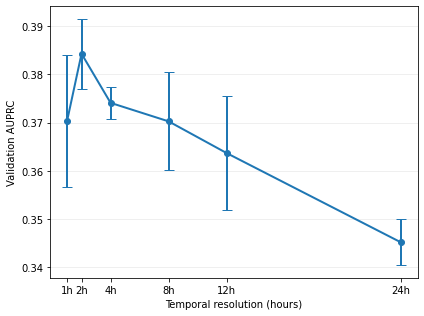

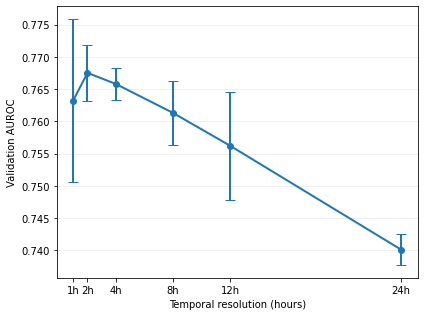

In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t


RESULTS_DIR = Path("/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality")
TIMESTEPS = [1, 2, 4, 8, 12, 24]


def load_results():
    rows = []

    for timestep in TIMESTEPS:
        log_dir = RESULTS_DIR / f"{timestep}h" / "keras_logs"

        # Only use seeded runs; ignore the older unseeded CSVs.
        files = sorted(log_dir.glob("*.seed*.csv"))

        for path in files:
            match = re.search(r"seed(\d+)", path.name)
            if match is None:
                continue

            seed = int(match.group(1))

            # Logs are semicolon-separated.
            df = pd.read_csv(path, sep=";")

            # Select checkpoint/epoch by validation AUPRC.
            best_idx = df["val_auprc"].idxmax()
            best = df.loc[best_idx]

            rows.append(
                {
                    "timestep": timestep,
                    "seed": seed,
                    "epoch": int(best["epoch"]),
                    "auprc": best["val_auprc"],
                    # AUROC from the SAME selected epoch.
                    "auroc": best["val_auroc"],
                }
            )

    return pd.DataFrame(rows)


def summarize(df, metric):
    rows = []

    for timestep, group in df.groupby("timestep"):
        values = np.asarray(group[metric].values)
        n = len(values)

        mean = values.mean()
        sd = values.std(ddof=1)
        sem = sd / np.sqrt(n)

        # Two-sided 95% Student-t confidence interval.
        critical = t.ppf(0.975, df=n - 1)
        ci = critical * sem

        rows.append(
            {
                "timestep": timestep,
                "mean": mean,
                "sd": sd,
                "ci95": ci,
                "n": n,
            }
        )

    return pd.DataFrame(rows).sort_values("timestep")


def plot_metric(summary, metric_name, output_file):
    x = np.asarray(summary["timestep"].values)
    y = np.asarray(summary["mean"].values)
    ci = np.asarray(summary["ci95"].values)

    plt.figure(figsize=(6, 4.5))

    plt.errorbar(
        x,
        y,
        yerr=ci,
        marker="o",
        capsize=5,
        linewidth=2,
        markersize=6,
    )

    plt.xlabel("Temporal resolution (hours)")
    plt.ylabel(metric_name)
    plt.xticks(TIMESTEPS, [f"{x}h" for x in TIMESTEPS])

    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    # plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()


df = load_results()

print("\nSelected runs:")
print(df.to_string(index=False))

auprc_summary = summarize(df, "auprc")
auroc_summary = summarize(df, "auroc")

print("\nAUPRC:")
print(auprc_summary.to_string(index=False))

print("\nAUROC:")
print(auroc_summary.to_string(index=False))

plot_metric(
    auprc_summary,
    metric_name="Validation AUPRC",
    output_file="experiment1_auprc_ci.png",
)

plot_metric(
    auroc_summary,
    metric_name="Validation AUROC",
    output_file="experiment1_auroc_ci.png",
)

In [3]:
from pathlib import Path
import re
import subprocess
import pandas as pd


# ---------------------------------------------------------------------
# Paths / experiment settings
# ---------------------------------------------------------------------

DATA = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/data/in-hospital-mortality"
)

NORM = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/normalizers"
)

# Change this if your Experiment 1 results are stored somewhere else.
# Expected structure:
#
# OUT/
# ├── 1h/
# │   ├── keras_logs/
# │   └── keras_states/
# ├── 2h/
# ├── 4h/
# ...
OUT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality"
)

NETWORK = "mimic4models/keras_models/lstm.py"

TIMESTEPS = [1, 2, 4, 8, 12, 16, 24]
SEEDS = [0, 1, 2, 3, 4]

ONLY_COMPLETE = False
EXPECTED_EPOCHS = 100


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def parse_run_from_filename(path):
    """
    Example filename:
    k_lstm.n16.d0.3.dep2.bs8.ts8.0.seed0.csv
    """
    m = re.search(
        r"\.ts(?P<timestep>[0-9.]+)"
        r".*\.seed(?P<seed>\d+)\.csv$",
        path.name,
    )

    if m is None:
        return None

    return {
        "timestep": float(m.group("timestep")),
        "seed": int(m.group("seed")),
    }


def find_best_epoch(log_path):
    """
    Select checkpoint using highest validation AUPRC.
    AUROC is reported from the same epoch.
    """
    df = pd.read_csv(str(log_path), sep=";")

    if len(df) == 0:
        return None

    if ONLY_COMPLETE and len(df) < EXPECTED_EPOCHS:
        return None

    best_idx = df["val_auprc"].idxmax()
    row = df.loc[best_idx]

    return {
        "csv_epoch": int(row["epoch"]),
        "val_auprc": float(row["val_auprc"]),
        "val_auroc": float(row["val_auroc"]),
        "n_epochs": len(df),
    }


def find_checkpoint(log_path, csv_epoch):
    """
    CSVLogger epoch is zero-indexed, while checkpoint filenames generated
    with {epoch} are normally one-indexed.

    Therefore CSV epoch 17 corresponds to checkpoint epoch18.
    """
    state_dir = log_path.parent.parent / "keras_states"

    checkpoint_epoch = csv_epoch + 1
    base = log_path.stem

    candidates = list(
        state_dir.glob(
            "{}.epoch{}.test*.state".format(
                base,
                checkpoint_epoch,
            )
        )
    )

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) == 0:
        return None

    raise RuntimeError(
        "Multiple checkpoints found for {} epoch {}:\n{}".format(
            log_path.name,
            checkpoint_epoch,
            candidates,
        )
    )


def find_normalizer(timestep):
    """
    Find the normalizer created by mimic4models.create_normalizer_state.

    Expected style:
    ihm_ts:8.00_impute:previous_start:zero_masks:True_n:*.normalizer
    """
    pattern = (
        "ihm_ts:{:.2f}_impute:previous_start:zero_masks:True_n:*.normalizer"
        .format(timestep)
    )

    candidates = list(NORM.glob(pattern))

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) == 0:
        raise RuntimeError(
            "No normalizer found for timestep {}h using:\n{}".format(
                timestep,
                NORM / pattern,
            )
        )

    raise RuntimeError(
        "Multiple normalizers found for timestep {}h:\n{}".format(
            timestep,
            candidates,
        )
    )


def parse_test_metrics(stdout):
    """
    Parse metrics printed by print_metrics_binary().
    """
    auroc = None
    auprc = None

    m = re.search(r"AUC of ROC = ([0-9.eE+-]+)", stdout)
    if m:
        auroc = float(m.group(1))

    m = re.search(r"AUC of PRC = ([0-9.eE+-]+)", stdout)
    if m:
        auprc = float(m.group(1))

    return auroc, auprc


# ---------------------------------------------------------------------
# Evaluate all available Experiment 1 runs
# ---------------------------------------------------------------------

rows = []

for timestep in TIMESTEPS:

    log_dir = OUT / "{}h".format(timestep) / "keras_logs"

    if not log_dir.exists():
        print("Missing log directory: {}".format(log_dir))
        continue

    normalizer = find_normalizer(float(timestep))

    for log_path in sorted(log_dir.glob("*.csv")):

        run = parse_run_from_filename(log_path)

        # Ignore old unseeded logs.
        if run is None:
            continue

        # Protect against files being in the wrong timestep directory.
        if abs(run["timestep"] - timestep) > 1e-6:
            continue

        best = find_best_epoch(log_path)

        if best is None:
            print("Skipping incomplete/empty run: {}".format(log_path.name))
            continue

        checkpoint = find_checkpoint(
            log_path,
            best["csv_epoch"],
        )

        if checkpoint is None:
            print(
                "Checkpoint missing: "
                "ts={} seed={} best_csv_epoch={}".format(
                    run["timestep"],
                    run["seed"],
                    best["csv_epoch"],
                )
            )
            continue

        print(
            "\n"
            + "=" * 80
            + "\ntimestep={}h seed={}".format(
                run["timestep"],
                run["seed"],
            )
            + "\nbest val epoch={}".format(best["csv_epoch"])
            + " val AUPRC={:.6f}".format(best["val_auprc"])
            + " val AUROC={:.6f}".format(best["val_auroc"])
            + "\ncheckpoint={}".format(checkpoint.name)
            + "\nnormalizer={}".format(normalizer.name)
            + "\n"
            + "=" * 80
        )

        cmd = [
            "python",
            "-u",
            "-m",
            "mimic4models.in_hospital_mortality.main",

            "--network",
            NETWORK,

            "--dim",
            "16",

            "--depth",
            "2",

            "--dropout",
            "0.3",

            "--mode",
            "test",

            "--batch_size",
            "8",

            "--timestep",
            str(run["timestep"]),

            "--seed",
            str(run["seed"]),

            "--data",
            str(DATA),

            "--normalizer_state",
            str(normalizer),

            "--output_dir",
            str(OUT / "{}h".format(timestep)),

            "--load_state",
            str(checkpoint),
        ]

        result = subprocess.run(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            universal_newlines=True,
        )

        if result.returncode != 0:
            print("TEST FAILED")
            print(result.stderr)
            continue

        print(result.stdout)

        test_auroc, test_auprc = parse_test_metrics(
            result.stdout
        )

        rows.append(
            {
                "timestep": run["timestep"],
                "seed": run["seed"],
                "n_epochs": best["n_epochs"],
                "best_csv_epoch": best["csv_epoch"],
                "checkpoint_epoch": best["csv_epoch"] + 1,
                "val_auprc": best["val_auprc"],
                "val_auroc": best["val_auroc"],
                "test_auprc": test_auprc,
                "test_auroc": test_auroc,
            }
        )


# ---------------------------------------------------------------------
# Print run-level test results
# ---------------------------------------------------------------------

results_exp1 = pd.DataFrame(rows)

if len(results_exp1) == 0:
    print("\nNo test results produced.")

else:
    results_exp1 = (
        results_exp1
        .sort_values(["timestep", "seed"])
        .reset_index(drop=True)
    )

    print("\n\nEXPERIMENT 1 TEST RESULTS")
    print("=" * 100)

    print(
        results_exp1.to_string(
            index=False,
            float_format=lambda x: "{:.6f}".format(x),
        )
    )


timestep=1.0h seed=0
best val epoch=94 val AUPRC=0.373447 val AUROC=0.770488
checkpoint=k_lstm.n16.d0.3.dep2.bs8.ts1.0.seed0.epoch95.test0.3215087160013621.state
normalizer=ihm_ts:1.00_impute:previous_start:zero_masks:True_n:15579.normalizer


KeyboardInterrupt: 

In [ ]:
summary_exp1 = (
    results_exp1
    .groupby("timestep")
    .agg({
        "seed": "count",
        "test_auprc": ["mean", "std"],
        "test_auroc": ["mean", "std"],
    })
    .reset_index()
)

# Flatten the multi-level column names
summary_exp1.columns = [
    "timestep",
    "n",
    "auprc_mean",
    "auprc_sd",
    "auroc_mean",
    "auroc_sd",
]

print(
    summary_exp1.to_string(
        index=False,
        float_format=lambda x: "{:.4f}".format(x),
    )
)

NameError: name 'results_exp1' is not defined

In [ ]:
reference = (
    results_exp1[results_exp1["timestep"] == 1]
    [["seed", "test_auprc", "test_auroc"]]
    .rename(
        columns={
            "test_auprc": "auprc_1h",
            "test_auroc": "auroc_1h",
        }
    )
)

drops_exp1 = results_exp1.merge(
    reference,
    on="seed",
    how="inner",
)

drops_exp1["auprc_drop"] = (
    drops_exp1["auprc_1h"]
    - drops_exp1["test_auprc"]
)

drops_exp1["auroc_drop"] = (
    drops_exp1["auroc_1h"]
    - drops_exp1["test_auroc"]
)

drop_summary_exp1 = (
    drops_exp1
    .groupby("timestep")
    .agg(
        n=("seed", "count"),
        auprc_drop_mean=("auprc_drop", "mean"),
        auprc_drop_sd=("auprc_drop", "std"),
        auroc_drop_mean=("auroc_drop", "mean"),
        auroc_drop_sd=("auroc_drop", "std"),
    )
    .reset_index()
)

print(
    drop_summary_exp1.to_string(
        index=False,
        float_format=lambda x: "{:.4f}".format(x),
    )
)

# experiment 2


Selected best validation checkpoints:
horizon  timestep  seed  n_epochs  best_epoch     auprc     auroc
     12       1.0     0       100          93  0.469834  0.730083
     12       1.0     1       100          44  0.476230  0.731720
     12       1.0     2       100          91  0.471504  0.736019
     12       2.0     0       100          63  0.471126  0.727930
     12       2.0     1       100          37  0.469171  0.727814
     12       2.0     2       100          64  0.470541  0.729149
     12       2.0     3       100          73  0.471056  0.730254
     12       2.0     4       100          70  0.472521  0.730681
     12       4.0     0       100          99  0.445222  0.714791
     12       4.0     1       100          80  0.446050  0.714950
     12       4.0     2       100          92  0.443186  0.711262
     12       4.0     3       100          66  0.443601  0.712094
     12       4.0     4       100          95  0.445579  0.716713
     12       8.0     0       100    

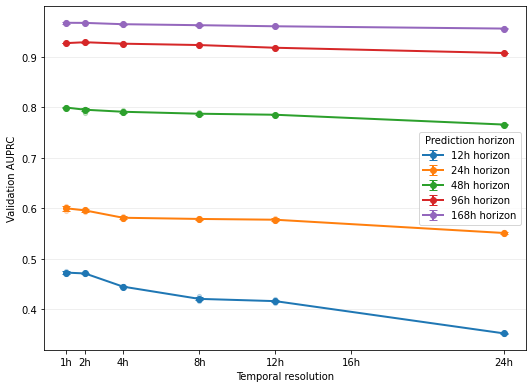

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/auprc_vs_timestep.png


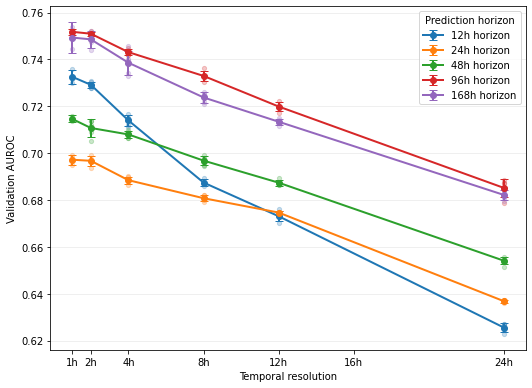

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/auroc_vs_timestep.png


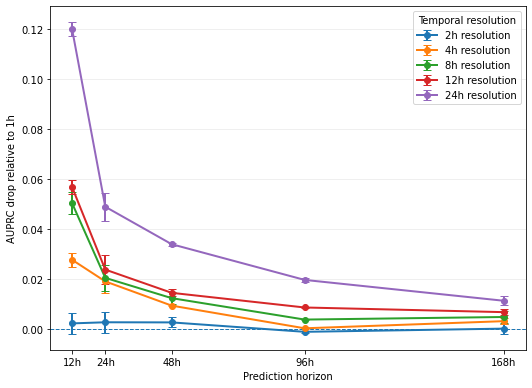

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/auprc_drop_from_1h_vs_horizon.png


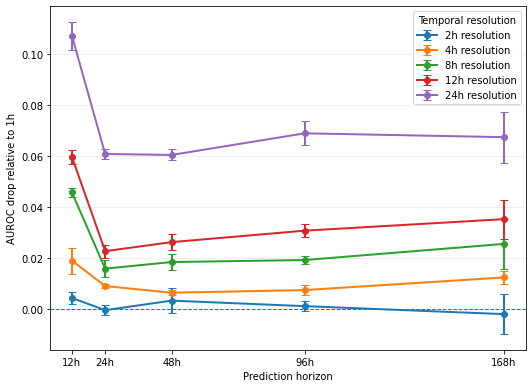

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/auroc_drop_from_1h_vs_horizon.png


In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

RESULTS_DIR = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/results/"
    "fixed_horizon_icu_exit"
)

HORIZONS = [12, 24, 48, 96, 168]
TIMESTEPS = [1, 2, 4, 8, 12, 16, 24]

EXPECTED_SEEDS = {0, 1, 2, 3, 4}

# For the final paper results, you may want to change this to True.
# Currently False so you can visualize partially completed experiments.
ONLY_COMPLETE_RUNS = False
EXPECTED_EPOCHS = 100

OUTPUT_DIR = RESULTS_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Load results
# ---------------------------------------------------------------------

def load_results():
    rows = []

    pattern = re.compile(
        r"\.h(?P<horizon>\d+)"
        r".*\.ts(?P<timestep>[0-9.]+)"
        r"\.seed(?P<seed>\d+)\.csv$"
    )

    for path in RESULTS_DIR.glob("*h/keras_logs/*.csv"):
        match = pattern.search(path.name)

        if match is None:
            print(f"Skipping unrecognized filename: {path}")
            continue

        horizon = int(match.group("horizon"))
        timestep = float(match.group("timestep"))
        seed = int(match.group("seed"))

        df = pd.read_csv(path, sep=";")

        if len(df) == 0:
            print(f"Skipping empty file: {path}")
            continue

        n_epochs = len(df)

        if ONLY_COMPLETE_RUNS and n_epochs < EXPECTED_EPOCHS:
            print(
                f"Skipping incomplete run: "
                f"h={horizon}, ts={timestep}, seed={seed}, "
                f"epochs={n_epochs}"
            )
            continue

        # Model selection:
        # choose epoch using validation AUPRC.
        best_idx = df["val_auprc"].idxmax()
        best = df.loc[best_idx]

        rows.append(
            {
                "horizon": horizon,
                "timestep": timestep,
                "seed": seed,
                "n_epochs": n_epochs,
                "best_epoch": int(best["epoch"]),
                "auprc": float(best["val_auprc"]),
                # AUROC from the SAME selected checkpoint.
                "auroc": float(best["val_auroc"]),
                "path": str(path),
            }
        )

    results = pd.DataFrame(rows)

    if len(results) == 0:
        raise RuntimeError("No result files found.")

    return results.sort_values(
        ["horizon", "timestep", "seed"]
    ).reset_index(drop=True)


# ---------------------------------------------------------------------
# Summary utilities
# ---------------------------------------------------------------------

def summarize(results, metric):
    summary = (
        results
        .groupby(["horizon", "timestep"])[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"std": "sd", "count": "n"})
    )

    # SD is undefined for n=1; use 0 only for plotting the current
    # incomplete results. The table still reports n.
    summary["sd_plot"] = summary["sd"].fillna(0)

    return summary


def print_coverage(results):
    print("\nRun coverage:")
    print("-" * 70)

    for horizon in HORIZONS:
        for timestep in TIMESTEPS:
            sub = results[
                (results["horizon"] == horizon)
                & (results["timestep"] == timestep)
            ]

            seeds = set(sub["seed"].tolist())
            missing = EXPECTED_SEEDS - seeds

            print(
                f"h={horizon:>3}h  "
                f"ts={timestep:>4}h  "
                f"n={len(seeds)}  "
                f"seeds={sorted(seeds)}"
                + (
                    f"  missing={sorted(missing)}"
                    if missing
                    else ""
                )
            )


# ---------------------------------------------------------------------
# Figure 1:
# performance vs temporal resolution
# ---------------------------------------------------------------------

def plot_performance_vs_timestep(results, metric):
    summary = summarize(results, metric)

    plt.figure(figsize=(7.5, 5.5))

    for horizon in HORIZONS:
        sub = summary[
            summary["horizon"] == horizon
        ].sort_values("timestep")

        if len(sub) == 0:
            continue

        plt.errorbar(
            sub["timestep"],
            sub["mean"],
            yerr=sub["sd_plot"],
            marker="o",
            capsize=4,
            linewidth=2,
            label=f"{horizon}h horizon",
        )

        # Show individual seed results.
        raw = results[results["horizon"] == horizon]

        plt.scatter(
            raw["timestep"],
            raw[metric],
            alpha=0.25,
            s=18,
        )

    plt.xticks(
        TIMESTEPS,
        [f"{x}h" for x in TIMESTEPS],
    )

    plt.xlabel("Temporal resolution")
    plt.ylabel(
        "Validation AUPRC"
        if metric == "auprc"
        else "Validation AUROC"
    )

    plt.legend(title="Prediction horizon")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    path = OUTPUT_DIR / f"{metric}_vs_timestep.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {path}")


# ---------------------------------------------------------------------
# Compute paired drop from 1h
#
# For each seed:
#
# drop(h, r, s) =
#     metric(h, 1h, s) - metric(h, r, s)
#
# Positive = coarsening hurts performance.
# ---------------------------------------------------------------------

def compute_paired_drops(results, metric):
    reference = (
        results[results["timestep"] == 1]
        [["horizon", "seed", metric]]
        .rename(columns={metric: "reference"})
    )

    merged = results.merge(
        reference,
        on=["horizon", "seed"],
        how="inner",
    )

    merged["drop"] = (
        merged["reference"] - merged[metric]
    )

    return merged


# ---------------------------------------------------------------------
# Figure 2:
# drop relative to 1h vs prediction horizon
#
# x = prediction horizon
# one line for each temporal resolution
# ---------------------------------------------------------------------

def plot_drop_vs_horizon(results, metric):
    drops = compute_paired_drops(results, metric)

    # Don't plot 1h against itself.
    drops = drops[drops["timestep"] != 1]

    summary = (
        drops
        .groupby(["horizon", "timestep"])["drop"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"std": "sd", "count": "n"})
    )

    summary["sd_plot"] = summary["sd"].fillna(0)

    plt.figure(figsize=(7.5, 5.5))

    for timestep in TIMESTEPS:
        if timestep == 1:
            continue

        sub = summary[
            summary["timestep"] == timestep
        ].sort_values("horizon")

        if len(sub) == 0:
            continue

        plt.errorbar(
            sub["horizon"],
            sub["mean"],
            yerr=sub["sd_plot"],
            marker="o",
            capsize=4,
            linewidth=2,
            label=f"{timestep}h resolution",
        )

    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xticks(
        HORIZONS,
        [f"{h}h" for h in HORIZONS],
    )

    plt.xlabel("Prediction horizon")

    if metric == "auprc":
        plt.ylabel("AUPRC drop relative to 1h")
    else:
        plt.ylabel("AUROC drop relative to 1h")

    plt.legend(title="Temporal resolution")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    path = OUTPUT_DIR / f"{metric}_drop_from_1h_vs_horizon.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {path}")

    return summary


# ---------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------

results = load_results()

print("\nSelected best validation checkpoints:")
print(
    results[
        [
            "horizon",
            "timestep",
            "seed",
            "n_epochs",
            "best_epoch",
            "auprc",
            "auroc",
        ]
    ].to_string(index=False)
)

print_coverage(results)


# Save selected run-level results.
results.to_csv(
    OUTPUT_DIR / "selected_runs.csv",
    index=False,
)


# Performance curves
plot_performance_vs_timestep(
    results,
    metric="auprc",
)

plot_performance_vs_timestep(
    results,
    metric="auroc",
)


# Paired degradation curves
auprc_drops = plot_drop_vs_horizon(
    results,
    metric="auprc",
)

auroc_drops = plot_drop_vs_horizon(
    results,
    metric="auroc",
)


auprc_drops.to_csv(
    OUTPUT_DIR / "auprc_drop_summary.csv",
    index=False,
)

auroc_drops.to_csv(
    OUTPUT_DIR / "auroc_drop_summary.csv",
    index=False,
)

In [5]:
from pathlib import Path
import re
import subprocess
import pandas as pd


# ---------------------------------------------------------------------
# Paths / experiment settings
# ---------------------------------------------------------------------

DATA = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/data/length-of-stay"
)

NORM = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/normalizers"
)

OUT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit"
)

NETWORK = "mimic4models/keras_models/lstm.py"

HORIZONS = [12, 24, 48, 96, 168]
TIMESTEPS = [1, 2, 4, 8, 12, 16, 24]
SEEDS = [0, 1, 2, 3, 4]


# Set to True once you only want fully finished runs.
ONLY_COMPLETE = False
EXPECTED_EPOCHS = 100


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def parse_run_from_filename(path):
    """
    Extract horizon, timestep, seed from filenames like:
    ...h12....ts8.0....seed0.csv
    """
    m = re.search(
        r"\.h(?P<horizon>\d+)"
        r".*\.ts(?P<timestep>[0-9.]+)"
        r".*\.seed(?P<seed>\d+)\.csv$",
        path.name,
    )

    if m is None:
        return None

    return {
        "horizon": int(m.group("horizon")),
        "timestep": float(m.group("timestep")),
        "seed": int(m.group("seed")),
    }


def find_best_epoch(log_path):
    """
    Select checkpoint using highest validation AUPRC.
    """
    df = pd.read_csv(log_path, sep=";")

    if len(df) == 0:
        return None

    if ONLY_COMPLETE and len(df) < EXPECTED_EPOCHS:
        return None

    best_idx = df["val_auprc"].idxmax()
    row = df.loc[best_idx]

    return {
        "csv_epoch": int(row["epoch"]),
        "val_auprc": float(row["val_auprc"]),
        "val_auroc": float(row["val_auroc"]),
        "n_epochs": len(df),
    }


def find_checkpoint(log_path, csv_epoch):
    """
    Keras CSVLogger uses zero-indexed epochs while ModelCheckpoint's
    {epoch} filename is normally one-indexed.

    Therefore CSV epoch 17 usually corresponds to checkpoint epoch18.

    We verify this by looking for the actual state file.
    """
    state_dir = log_path.parent.parent / "keras_states"

    checkpoint_epoch = csv_epoch + 1

    # Match the exact run name, replacing .csv with .epochXX...
    base = log_path.stem

    candidates = list(
        state_dir.glob(
            f"{base}.epoch{checkpoint_epoch}.test*.state"
        )
    )

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) == 0:
        return None

    raise RuntimeError(
        f"Multiple checkpoints found for {log_path.name}, "
        f"epoch {checkpoint_epoch}:\n{candidates}"
    )


def parse_test_metrics(stdout):
    """
    Parse metrics printed by mimic4models.metrics.print_metrics_binary().
    """
    auroc = None
    auprc = None

    m = re.search(r"AUC of ROC = ([0-9.eE+-]+)", stdout)
    if m:
        auroc = float(m.group(1))

    m = re.search(r"AUC of PRC = ([0-9.eE+-]+)", stdout)
    if m:
        auprc = float(m.group(1))

    return auroc, auprc


# ---------------------------------------------------------------------
# Find all runs and evaluate them
# ---------------------------------------------------------------------

rows = []

for horizon in HORIZONS:
    log_dir = OUT / f"{horizon}h" / "keras_logs"

    if not log_dir.exists():
        print(f"Missing log directory: {log_dir}")
        continue

    for log_path in sorted(log_dir.glob("*.csv")):

        run = parse_run_from_filename(log_path)

        if run is None:
            continue

        # Sanity check directory vs filename.
        if run["horizon"] != horizon:
            continue

        best = find_best_epoch(log_path)

        if best is None:
            print(f"Skipping incomplete/empty run: {log_path.name}")
            continue

        checkpoint = find_checkpoint(
            log_path,
            best["csv_epoch"],
        )

        if checkpoint is None:
            print(
                f"Checkpoint missing: "
                f"h={run['horizon']} "
                f"ts={run['timestep']} "
                f"seed={run['seed']} "
                f"best_csv_epoch={best['csv_epoch']}"
            )
            continue

        print(
            "\n"
            + "=" * 80
            + f"\nhorizon={run['horizon']}h"
            + f" timestep={run['timestep']}h"
            + f" seed={run['seed']}"
            + f"\nbest val epoch={best['csv_epoch']}"
            + f" val AUPRC={best['val_auprc']:.6f}"
            + f" val AUROC={best['val_auroc']:.6f}"
            + f"\ncheckpoint={checkpoint.name}"
            + "\n"
            + "=" * 80
        )

        cmd = [
            "python",
            "-u",
            "-m",
            "mimic4models.fixed_horizon_icu_exit.main",

            "--network",
            NETWORK,

            "--dim",
            "16",

            "--depth",
            "2",

            "--dropout",
            "0.3",

            "--mode",
            "test",

            "--batch_size",
            "8",

            "--timestep",
            str(run["timestep"]),

            "--horizon",
            str(run["horizon"]),

            "--seed",
            str(run["seed"]),

            "--data",
            str(DATA),

            "--normalizer_dir",
            str(NORM),

            "--output_dir",
            str(OUT / f"{run['horizon']}h"),

            "--load_state",
            str(checkpoint),
        ]

        result = subprocess.run(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            universal_newlines=True,
        )

        if result.returncode != 0:
            print("TEST FAILED")
            print(result.stderr)
            continue

        # Print the benchmark's test output.
        print(result.stdout)

        test_auroc, test_auprc = parse_test_metrics(
            result.stdout
        )

        rows.append(
            {
                "horizon": run["horizon"],
                "timestep": run["timestep"],
                "seed": run["seed"],
                "n_epochs": best["n_epochs"],
                "best_csv_epoch": best["csv_epoch"],
                "checkpoint_epoch": best["csv_epoch"] + 1,
                "val_auprc": best["val_auprc"],
                "val_auroc": best["val_auroc"],
                "test_auprc": test_auprc,
                "test_auroc": test_auroc,
            }
        )


# ---------------------------------------------------------------------
# Print final summary
# ---------------------------------------------------------------------

results = pd.DataFrame(rows)

if len(results) == 0:
    print("\nNo test results produced.")
else:
    results = results.sort_values(
        ["horizon", "timestep", "seed"]
    ).reset_index(drop=True)

    print("\n\nFINAL TEST RESULTS")
    print("=" * 100)

    print(
        results.to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}",
        )
    )


horizon=12h timestep=1.0h seed=0
best val epoch=93 val AUPRC=0.469834 val AUROC=0.730083
checkpoint=k_lstm.n16.d0.3.dep2.h12.bs8.ts1.0.seed0.epoch94.test0.5119056583997604.state
Namespace(batch_norm=False, batch_size=8, beta_1=0.9, data='/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/data/length-of-stay', depth=2, dim=16, dropout=0.3, epochs=100, horizon=12, imputation='previous', l1=0, l2=0, load_state='/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/12h/keras_states/k_lstm.n16.d0.3.dep2.h12.bs8.ts1.0.seed0.epoch94.test0.5119056583997604.state', lr=0.001, mode='test', network='mimic4models/keras_models/lstm.py', normalizer_dir='/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/normalizers', normalizer_state=None, optimizer='adam', output_dir='/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1

In [ ]:
summary = (
    results
    .groupby(["horizon", "timestep"])
    .agg({
        "seed": "count",
        "test_auprc": ["mean", "std"],
        "test_auroc": ["mean", "std"],
    })
    .reset_index()
)

summary.columns = [
    "horizon",
    "timestep",
    "n",
    "auprc_mean",
    "auprc_sd",
    "auroc_mean",
    "auroc_sd",
]

print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

horizon  timestep  n  auprc_mean  auprc_sd  auroc_mean  auroc_sd
     12    1.0000  3      0.4847    0.0105      0.7403    0.0073
     12    2.0000  4      0.4826    0.0026      0.7395    0.0010
     12    4.0000  5      0.4671    0.0030      0.7341    0.0017
     12    8.0000  5      0.4124    0.0045      0.6936    0.0028
     12   12.0000  5      0.4163    0.0019      0.6877    0.0023
     12   24.0000  5      0.3386    0.0036      0.6247    0.0034
     24    1.0000  2      0.6100    0.0063      0.7026    0.0036
     24    2.0000  4      0.6004    0.0046      0.6954    0.0024
     24    4.0000  5      0.5985    0.0030      0.6941    0.0019
     24    8.0000  5      0.5786    0.0023      0.6750    0.0013
     24   12.0000  5      0.5730    0.0014      0.6677    0.0007
     24   24.0000  5      0.5498    0.0014      0.6312    0.0013
     48    1.0000  2      0.7891    0.0009      0.7081    0.0012
     48    2.0000  4      0.7863    0.0022      0.7038    0.0024
     48    4.0000  5     

In [10]:
from pathlib import Path
import re

import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    brier_score_loss,
)


# ============================================================
# Configuration
# ============================================================

OUT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/results/"
    "fixed_horizon_icu_exit"
)

HORIZONS = [12, 24, 48, 96, 168]
TIMESTEPS = [1, 2, 4, 8, 12, 16, 24]
SEEDS = [0, 1, 2, 3, 4]

N_BOOT = 2000
BOOTSTRAP_SEED = 12345


# ============================================================
# Metrics
# ============================================================

def compute_auprc(y, pred):
    """
    Match mimic4models.metrics.print_metrics_binary():
    precision_recall_curve + trapezoidal AUC.
    """
    precision, recall, _ = precision_recall_curve(y, pred)
    return auc(recall, precision)


def compute_metric(y, pred, metric):
    y = np.asarray(y)
    pred = np.asarray(pred)

    if metric == "auroc":
        # AUROC undefined if bootstrap sample has one class.
        if len(np.unique(y)) < 2:
            return np.nan
        return roc_auc_score(y, pred)

    elif metric == "auprc":
        return compute_auprc(y, pred)

    elif metric == "brier":
        return brier_score_loss(y, pred)

    else:
        raise ValueError("Unknown metric: {}".format(metric))


# ============================================================
# Parse test prediction files
# ============================================================

def parse_exp2_prediction_file(path):
    """
    Expected filename contains something like:

      .h12....ts8.0....seed0....

    Returns horizon, timestep, seed.
    """
    m = re.search(
        r"\.h(?P<horizon>\d+)"
        r".*\.ts(?P<timestep>[0-9.]+)"
        r".*\.seed(?P<seed>\d+)",
        path.name,
    )

    if m is None:
        return None

    return {
        "horizon": int(m.group("horizon")),
        "timestep": float(m.group("timestep")),
        "seed": int(m.group("seed")),
    }


def extract_patient_id(stay):
    """
    MIMIC benchmark names usually look like:

        12345678_episode1_timeseries.csv

    We bootstrap at patient level, so use the subject ID prefix.

    If naming differs, this falls back to everything before the
    first underscore.
    """
    stay = str(stay)

    m = re.match(r"^(\d+)_episode", stay)

    if m:
        return m.group(1)

    return stay.split("_")[0]


def load_exp2_predictions():
    rows = []

    for horizon in HORIZONS:

        pred_dir = OUT / "{}h".format(horizon) / "test_predictions"

        if not pred_dir.exists():
            print("Missing:", pred_dir)
            continue

        for path in pred_dir.glob("*.csv"):

            run = parse_exp2_prediction_file(path)

            if run is None:
                print("Could not parse:", path.name)
                continue

            df = pd.read_csv(path)

            required = {"stay", "prediction", "y_true"}

            if not required.issubset(df.columns):
                print("Missing columns:", path)
                continue

            df["patient_id"] = df["stay"].apply(extract_patient_id)

            rows.append({
                "horizon": run["horizon"],
                "timestep": run["timestep"],
                "seed": run["seed"],
                "path": path,
                "df": df,
            })

    return rows


predictions_exp2 = load_exp2_predictions()

print("Prediction files found:", len(predictions_exp2))

Prediction files found: 131


In [11]:
def paired_patient_bootstrap(
    reference_df,
    comparison_df,
    metric,
    n_boot=2000,
    random_state=12345,
):
    """
    Compare reference vs comparison on exactly the same stays.

    Difference:
        reference metric - comparison metric

    Positive AUROC/AUPRC difference:
        coarsening hurts performance.

    For Brier:
        smaller is better, so we reverse the difference:
        comparison Brier - reference Brier

    Thus positive always means 1h performs better.
    """

    # --------------------------------------------------------
    # Pair exact test examples
    # --------------------------------------------------------

    ref = reference_df[
        ["stay", "patient_id", "y_true", "prediction"]
    ].rename(
        columns={
            "prediction": "pred_ref",
            "y_true": "y_ref",
        }
    )

    comp = comparison_df[
        ["stay", "patient_id", "y_true", "prediction"]
    ].rename(
        columns={
            "prediction": "pred_comp",
            "y_true": "y_comp",
        }
    )

    paired = ref.merge(
        comp,
        on=["stay", "patient_id"],
        how="inner",
    )

    # Same task/cohort should have identical labels.
    if not np.array_equal(
        paired["y_ref"].values,
        paired["y_comp"].values,
    ):
        raise ValueError("Labels differ between paired prediction files.")

    if len(paired) != len(reference_df) or len(paired) != len(comparison_df):
        raise ValueError(
            "Reference/comparison cohorts differ: "
            "paired={}, ref={}, comparison={}".format(
                len(paired),
                len(reference_df),
                len(comparison_df),
            )
        )

    y = paired["y_ref"].values

    # --------------------------------------------------------
    # Original point estimates
    # --------------------------------------------------------

    ref_metric = compute_metric(
        y,
        paired["pred_ref"].values,
        metric,
    )

    comp_metric = compute_metric(
        y,
        paired["pred_comp"].values,
        metric,
    )

    if metric == "brier":
        # Higher difference = coarsening is worse.
        observed_diff = comp_metric - ref_metric
    else:
        observed_diff = ref_metric - comp_metric

    # --------------------------------------------------------
    # Patient-level bootstrap
    # --------------------------------------------------------

    rng = np.random.RandomState(random_state)

    patient_ids = paired["patient_id"].unique()

    # Store row indices belonging to each patient.
    patient_to_indices = {
        pid: paired.index[
            paired["patient_id"] == pid
        ].values
        for pid in patient_ids
    }

    boot_diffs = []

    for _ in range(n_boot):

        sampled_patients = rng.choice(
            patient_ids,
            size=len(patient_ids),
            replace=True,
        )

        # If a patient is selected twice, all of that patient's
        # stays are included twice.
        sampled_indices = np.concatenate([
            patient_to_indices[pid]
            for pid in sampled_patients
        ])

        boot = paired.loc[sampled_indices]

        y_b = boot["y_ref"].values

        ref_b = compute_metric(
            y_b,
            boot["pred_ref"].values,
            metric,
        )

        comp_b = compute_metric(
            y_b,
            boot["pred_comp"].values,
            metric,
        )

        if np.isnan(ref_b) or np.isnan(comp_b):
            continue

        if metric == "brier":
            diff_b = comp_b - ref_b
        else:
            diff_b = ref_b - comp_b

        boot_diffs.append(diff_b)

    boot_diffs = np.asarray(boot_diffs)

    ci_low, ci_high = np.percentile(
        boot_diffs,
        [2.5, 97.5],
    )

    return {
        "reference": ref_metric,
        "comparison": comp_metric,
        "difference": observed_diff,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "n_patients": len(patient_ids),
        "n_stays": len(paired),
        "n_boot_valid": len(boot_diffs),
    }

In [12]:
# Make lookup:
# (horizon, timestep, seed) -> prediction dataframe

lookup_exp2 = {}

for x in predictions_exp2:
    key = (
        x["horizon"],
        x["timestep"],
        x["seed"],
    )

    # In case the test script was accidentally run more than once,
    # warn rather than silently overwrite.
    if key in lookup_exp2:
        print("WARNING: duplicate prediction file for", key)

    lookup_exp2[key] = x["df"]


bootstrap_rows = []

for horizon in HORIZONS:

    for seed in SEEDS:

        reference_key = (
            horizon,
            1.0,
            seed,
        )

        if reference_key not in lookup_exp2:
            continue

        reference_df = lookup_exp2[reference_key]

        for timestep in TIMESTEPS:

            if timestep == 1:
                continue

            comparison_key = (
                horizon,
                float(timestep),
                seed,
            )

            if comparison_key not in lookup_exp2:
                continue

            comparison_df = lookup_exp2[comparison_key]

            for metric in ["auroc", "auprc", "brier"]:

                result = paired_patient_bootstrap(
                    reference_df,
                    comparison_df,
                    metric=metric,
                    n_boot=N_BOOT,
                    random_state=(
                        BOOTSTRAP_SEED
                        + horizon * 100
                        + timestep * 10
                        + seed
                    ),
                )

                bootstrap_rows.append({
                    "horizon": horizon,
                    "timestep": timestep,
                    "seed": seed,
                    "metric": metric,

                    "reference_1h": result["reference"],
                    "comparison": result["comparison"],

                    "difference": result["difference"],
                    "ci_low": result["ci_low"],
                    "ci_high": result["ci_high"],

                    "n_patients": result["n_patients"],
                    "n_stays": result["n_stays"],
                })


bootstrap_exp2 = pd.DataFrame(bootstrap_rows)

bootstrap_exp2 = bootstrap_exp2.sort_values(
    ["metric", "horizon", "timestep", "seed"]
).reset_index(drop=True)

KeyboardInterrupt: 

In [ ]:
for metric in ["auroc", "auprc", "brier"]:

    print("\n")
    print("=" * 100)
    print(metric.upper())
    print("Positive difference = 1h performs better")
    print("=" * 100)

    sub = bootstrap_exp2[
        bootstrap_exp2["metric"] == metric
    ][
        [
            "horizon",
            "timestep",
            "seed",
            "reference_1h",
            "comparison",
            "difference",
            "ci_low",
            "ci_high",
        ]
    ]

    print(
        sub.to_string(
            index=False,
            float_format=lambda x: "{:.4f}".format(x),
        )
    )

In [ ]:
seed_summary_exp2 = (
    bootstrap_exp2
    .groupby(["metric", "horizon", "timestep"])
    .agg(
        n_seeds=("seed", "nunique"),
        mean_difference=("difference", "mean"),
        sd_difference=("difference", "std"),
    )
    .reset_index()
)

for metric in ["auroc", "auprc", "brier"]:

    print("\n")
    print("=" * 80)
    print("{}: DIFFERENCE ACROSS SEEDS".format(metric.upper()))
    print("=" * 80)

    sub = seed_summary_exp2[
        seed_summary_exp2["metric"] == metric
    ]

    print(
        sub.to_string(
            index=False,
            float_format=lambda x: "{:.4f}".format(x),
        )
    )